# Trabajo Práctico 1 - Ciclo de vida de Machine Learning

**Materia:** Tecnología Digital VI - Inteligencia Artificial  
**Dataset:** Telco Customer Churn  
**Integrantes:** *Completar con los nombres de los tres integrantes antes de entregar*  
**Semestre:** 2026 - 2.º semestre

---

Este notebook desarrolla dos problemas de clasificación con el mismo conjunto de datos. La Parte I predice la fuga de clientes (*churn*) y pone el foco en la prevención de *data leakage*, la validación y las métricas de negocio. La Parte II reformula el objetivo para predecir el tipo de contrato.

**Criterio rector:** el conjunto de test se reserva para una única evaluación final. Toda transformación que aprende parámetros (imputación, escalado y codificación) se ajusta dentro de un `Pipeline`, únicamente con datos de entrenamiento.


## 0. Preparación y reproducibilidad

Usamos una semilla fija para que la partición y los resultados sean reproducibles. La regresión logística es una base apropiada porque produce una frontera interpretable, admite probabilidades y permite observar con claridad el efecto del tratamiento del desbalance.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")


pandas: 3.0.5
NumPy: 2.4.6
scikit-learn: 1.9.0


# Parte I - El camino de los datos (Telco Churn)

## 1. Problema de negocio y carga de los datos

Una empresa de telecomunicaciones quiere identificar clientes con riesgo de abandonar el servicio. Cada fila representa un cliente y reúne datos demográficos, servicios contratados, forma de pago, antigüedad y cargos. El target `Churn` vale `Yes` cuando el cliente se fugó.

Anticipar la fuga permite dirigir acciones de retención. Sin embargo, el objetivo no es predecir “muchos No”: interesa encontrar una proporción útil de las fugas sin enviar descuentos indiscriminadamente. Por eso más adelante contrastamos *precision* y *recall* y no evaluamos el modelo solo con *accuracy*.


In [2]:
DATA_PATH = Path("dataset Telco Customer Churn.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATA_PATH.name}. Ejecute el notebook desde la carpeta del TP."
    )

df_raw = pd.read_csv(DATA_PATH)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
display(df_raw.head())


Filas: 7,043 | Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


### 1.1 Auditoría inicial

Antes de modelar distinguimos cuatro problemas diferentes: faltantes reales, cadenas vacías, duplicados e identificadores. `customerID` es único por persona: sirve para trazabilidad, pero no contiene una señal generalizable y permitirlo como predictor agregaría miles de categorías sin significado.


In [3]:
# Contamos cadenas vacías luego de quitar espacios; isna() por sí solo no las detecta.
blank_counts = pd.Series(0, index=df_raw.columns, dtype="int64")
object_columns = df_raw.select_dtypes(include=["object", "string"]).columns
for column in object_columns:
    blank_counts[column] = df_raw[column].astype("string").str.strip().eq("").sum()

audit = pd.DataFrame(
    {
        "tipo_original": df_raw.dtypes.astype(str),
        "valores_unicos": df_raw.nunique(dropna=False),
        "nulos_detectados": df_raw.isna().sum(),
        "cadenas_vacias": blank_counts,
    }
)
display(audit)
print(f"Filas duplicadas: {df_raw.duplicated().sum()}")
print(f"customerID duplicados: {df_raw['customerID'].duplicated().sum()}")


,tipo_original,valores_unicos,nulos_detectados,cadenas_vacias
customerID,str,7043,0,0
gender,str,2,0,0
SeniorCitizen,int64,2,0,0
Partner,str,2,0,0
Dependents,str,2,0,0
tenure,int64,73,0,0
PhoneService,str,2,0,0
MultipleLines,str,3,0,0
InternetService,str,3,0,0
OnlineSecurity,str,3,0,0


Filas duplicadas: 0
customerID duplicados: 0


### 1.2 Anomalía de `TotalCharges` y estrategia de faltantes

`TotalCharges` debería ser numérica, pero pandas la carga como texto porque contiene 11 valores formados solo por espacios. Si no lo detectáramos, un modelo podría:

- rechazar la columna al intentar escalarla;
- tratar cada importe como una categoría (miles de *dummies* sin sentido ordinal); o
- excluir silenciosamente una variable potencialmente informativa.

Primero convertimos los espacios en `NaN` y luego usamos `pd.to_numeric`. La auditoría muestra además que los 11 casos tienen `tenure = 0`: son cuentas recién iniciadas, sin cargos acumulados. Por conocimiento del dominio asignamos `TotalCharges = 0`; no usamos una estadística aprendida con todo el dataset. Imputarles la mediana global introduciría un acumulado ficticio muy alto. El pipeline mantendrá igualmente un imputador entrenado dentro de cada fold como protección frente a futuros faltantes.


In [4]:
df = df_raw.copy()

# Conversión determinística: todavía no se aprende ningún parámetro de los datos.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype("string").str.strip().replace("", np.nan),
    errors="coerce",
)

missing_total = df["TotalCharges"].isna()
display(
    df.loc[
        missing_total,
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"],
    ]
)

assert missing_total.sum() == 11, "Cambió la cantidad esperada de cargos vacíos."
assert df.loc[missing_total, "tenure"].eq(0).all(), (
    "Hay cargos faltantes que no corresponden a clientes nuevos; revisar la regla."
)

df.loc[missing_total, "TotalCharges"] = 0.0

# Es un indicador binario nominal, no una cantidad que deba escalarse.
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Sí"})

assert df["TotalCharges"].dtype.kind in "fc"
assert df.isna().sum().sum() == 0
print("Conversión validada. Nulos restantes:", int(df.isna().sum().sum()))


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.550,<NA>,No
753,3115-CZMZD,0,20.250,<NA>,No
936,5709-LVOEQ,0,80.850,<NA>,No
1082,4367-NUYAO,0,25.750,<NA>,No
1340,1371-DWPAZ,0,56.050,<NA>,No
3331,7644-OMVMY,0,19.850,<NA>,No
3826,3213-VVOLG,0,25.350,<NA>,No
4380,2520-SGTTA,0,20.000,<NA>,No
5218,2923-ARZLG,0,19.700,<NA>,No
6670,4075-WKNIU,0,73.350,<NA>,No


Conversión validada. Nulos restantes: 0


## 2. Análisis exploratorio

Las categorías `No internet service` y `No phone service` no son nulos: expresan que el servicio base no está contratado. Las conservamos como niveles con información propia. A continuación resumimos las variables numéricas y luego observamos relaciones relevantes con la fuga.


In [5]:
numeric_summary = df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T
categorical_summary = pd.DataFrame(
    {
        "categorías": df.select_dtypes(exclude="number").nunique(),
        "moda": df.select_dtypes(exclude="number").mode().iloc[0],
        "frecuencia_moda": [
            df[column].value_counts().iloc[0]
            for column in df.select_dtypes(exclude="number").columns
        ],
    }
)

print("Resumen de variables numéricas")
display(numeric_summary.round(2))
print("Resumen de variables categóricas")
display(categorical_summary)


Resumen de variables numéricas

,count,mean,std,min,25%,50%,75%,max
tenure,"7,043.000",32.371,24.559,0.000,9.000,29.000,55.000,72.000
MonthlyCharges,"7,043.000",64.762,30.090,18.250,35.500,70.350,89.850,118.750
TotalCharges,"7,043.000","2,279.734","2,266.794",0.000,398.550,"1,394.550","3,786.600","8,684.800"


Resumen de variables categóricas


,categorías,moda,frecuencia_moda
customerID,7043,0002-ORFBO,1
gender,2,Male,3555
SeniorCitizen,2,No,5901
Partner,2,No,3641
Dependents,2,No,4933
PhoneService,2,Yes,6361
MultipleLines,3,No,3390
InternetService,3,Fiber optic,3096
OnlineSecurity,3,No,3498
OnlineBackup,3,No,3088


### Visualización 1 - Balance de la variable objetivo

La clase positiva es minoritaria. Esto anticipa dos decisiones: estratificar las particiones para preservar la proporción y complementar *accuracy* con métricas enfocadas en `Churn = Yes`.


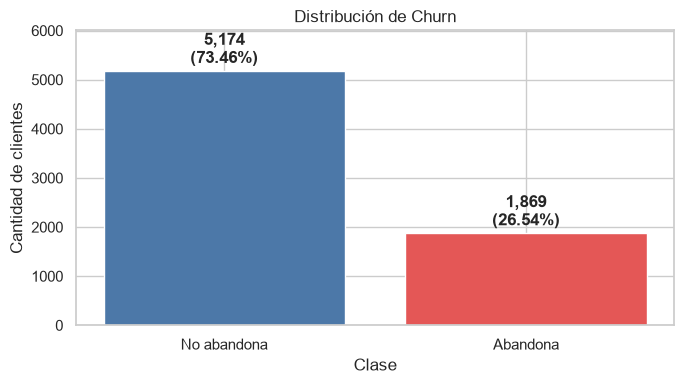

In [6]:
churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"])
churn_pct = 100 * churn_counts / churn_counts.sum()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["No abandona", "Abandona"], churn_counts, color=["#4C78A8", "#E45756"])
for bar, count, pct in zip(bars, churn_counts, churn_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 70,
        f"{count:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
ax.set(title="Distribución de Churn", xlabel="Clase", ylabel="Cantidad de clientes")
ax.set_ylim(0, churn_counts.max() * 1.16)
plt.tight_layout()
plt.show()


**Lectura:** 1.869 de 7.043 clientes abandonaron (26,54 %). Un modelo que siempre predijera la clase mayoritaria ya lograría 73,46 % de *accuracy*, aun cuando no detectaría una sola fuga.


### Visualización 2 - Tasa de fuga por tipo de contrato

Comparamos tasas y no cantidades absolutas, porque los tamaños de los grupos difieren.


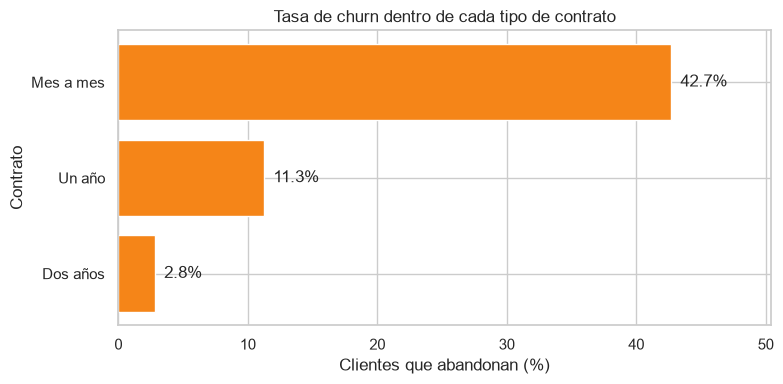

In [7]:
churn_by_contract = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index")["Yes"]
    .mul(100)
    .sort_values()
    .rename(index={"Month-to-month": "Mes a mes", "One year": "Un año", "Two year": "Dos años"})
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(churn_by_contract.index, churn_by_contract.values, color="#F58518")
for bar, value in zip(bars, churn_by_contract.values):
    ax.text(value + 0.7, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center")
ax.set(
    title="Tasa de churn dentro de cada tipo de contrato",
    xlabel="Clientes que abandonan (%)",
    ylabel="Contrato",
    xlim=(0, max(churn_by_contract.values) * 1.18),
)
plt.tight_layout()
plt.show()


**Lectura:** los contratos mes a mes presentan una tasa de fuga muy superior. Es una asociación predictiva, no una prueba causal: otros factores (antigüedad, servicios o precios) pueden influir simultáneamente.


### Visualización 3 - Antigüedad según fuga


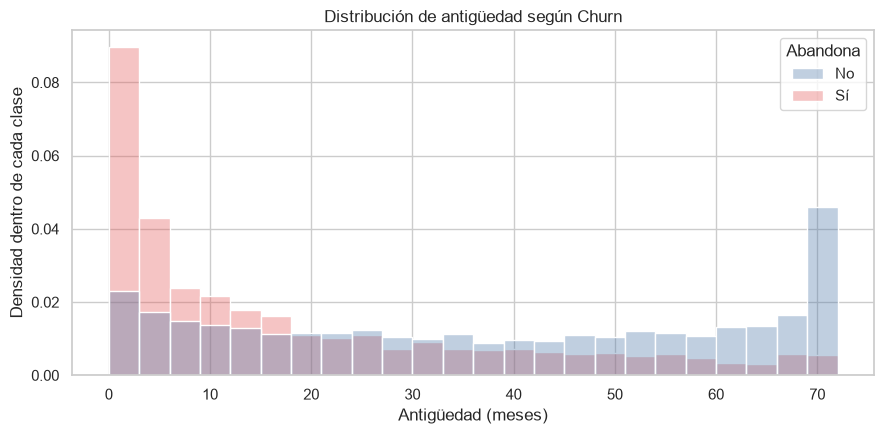

In [8]:
churn_plot_df = df.assign(
    Abandona=df["Churn"].map({"No": "No", "Yes": "Sí"})
)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(
    data=churn_plot_df,
    x="tenure",
    hue="Abandona",
    bins=24,
    stat="density",
    common_norm=False,
    alpha=0.35,
    palette={"No": "#4C78A8", "Sí": "#E45756"},
    ax=ax,
)
ax.set(
    title="Distribución de antigüedad según Churn",
    xlabel="Antigüedad (meses)",
    ylabel="Densidad dentro de cada clase",
)
plt.tight_layout()
plt.show()


**Lectura:** la fuga se concentra entre clientes de menor antigüedad. El uso de densidad dentro de cada clase evita que el mayor tamaño de la clase `No` domine visualmente la comparación.


### Visualización 4 - Cargos mensuales según fuga


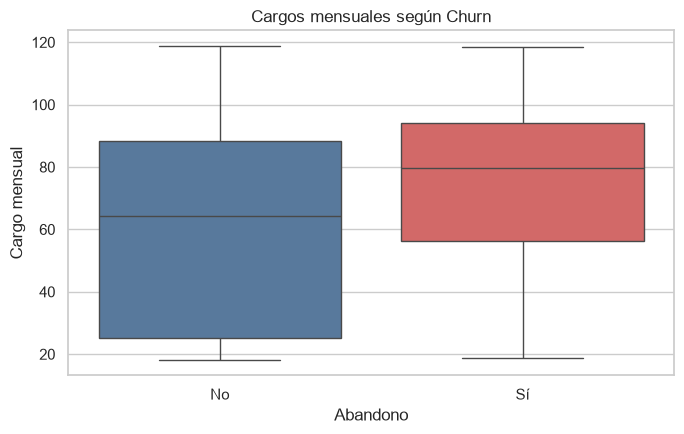

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(
    data=churn_plot_df,
    x="Abandona",
    y="MonthlyCharges",
    order=["No", "Sí"],
    hue="Abandona",
    palette={"No": "#4C78A8", "Sí": "#E45756"},
    legend=False,
    ax=ax,
)
ax.set(
    title="Cargos mensuales según Churn",
    xlabel="Abandono",
    ylabel="Cargo mensual",
)
plt.tight_layout()
plt.show()


**Lectura:** la mediana de `MonthlyCharges` es mayor entre quienes abandonan. La superposición de las cajas confirma que esta variable por sí sola no separa perfectamente las clases y debe combinarse con el resto.


## 3. División Train/Test y prevención de *data leakage*

El orden correcto es:

1. aplicar únicamente correcciones determinísticas que no aprenden del conjunto (por ejemplo, convertir texto a número y asignar 0 a cuentas con `tenure = 0`);
2. separar entrenamiento y test;
3. ajustar imputadores, escaladores y codificadores **solo con entrenamiento**;
4. reutilizar esos parámetros, sin recalcularlos, para transformar validación y test.

Si imputáramos o escaláramos antes del split, la mediana, la media y la desviación incluirían información del test. El modelo recibiría una pequeña “pista” sobre datos que deberían ser desconocidos: eso es *data leakage* y produce una evaluación demasiado optimista. Usar un `Pipeline` también evita la fuga entre folds durante validación cruzada, porque el preprocesamiento se reajusta desde cero dentro de cada fold de entrenamiento.


In [10]:
# customerID se excluye porque es un identificador único, no una característica generalizable.
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "filas": [len(X_train), len(X_test)],
        "churn_positivo_%": [100 * y_train.mean(), 100 * y_test.mean()],
    },
    index=["Train", "Test"],
)
display(split_summary.round(2))

assert X_train.index.intersection(X_test.index).empty
assert abs(y_train.mean() - y_test.mean()) < 0.001


,filas,churn_positivo_%
Train,5634,26.540
Test,1409,26.540


### 3.1 Pipeline de preprocesamiento

- **Numéricas:** imputación por mediana dentro del fold y `StandardScaler`. La regresión logística está regularizada; escalar evita que una unidad grande como `TotalCharges` condicione la penalización más que `tenure`.
- **Categóricas:** imputación por moda como protección y `OneHotEncoder`. `handle_unknown="ignore"` permite transformar una categoría que aparezca en test sin romper la ejecución.
- **Modelo:** regresión logística sin ajuste de hiperparámetros. `max_iter` solo garantiza convergencia; no aumenta la complejidad del modelo.


In [11]:
def build_logistic_pipeline(X_reference, class_weight=None):
    # Construye el pipeline sin ajustarlo: fit ocurre después del split.
    numeric_features = X_reference.select_dtypes(include="number").columns.tolist()
    categorical_features = X_reference.select_dtypes(exclude="number").columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ]
    )

    model = LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight=class_weight,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


base_pipeline = build_logistic_pipeline(X_train)
print("Variables numéricas:", X_train.select_dtypes(include="number").columns.tolist())
print("Variables categóricas:", X_train.select_dtypes(exclude="number").columns.tolist())


Variables numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Variables categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 4. Estrategia de validación: Stratified K-Fold (K=5)

Una sola partición *holdout* puede producir una estimación dependiente de qué observaciones cayeron al azar en validación. Con 5 folds, cada fila de entrenamiento se valida exactamente una vez y obtenemos media y dispersión de las métricas, por lo que la conclusión es más estable.

Usamos la variante estratificada porque solo 26,54 % de los casos son positivos. `StratifiedKFold` conserva aproximadamente esa tasa en cada fold; un K-Fold no estratificado podría generar folds con proporciones distintas y volver menos comparables sus métricas. La validación cruzada se realiza **solo sobre train**: test permanece reservado para el final.


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_balance = []
for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train), start=1):
    fold_balance.append(
        {
            "fold": fold,
            "n_train": len(train_idx),
            "n_validación": len(valid_idx),
            "positivos_train_%": 100 * y_train.iloc[train_idx].mean(),
            "positivos_validación_%": 100 * y_train.iloc[valid_idx].mean(),
        }
    )

display(pd.DataFrame(fold_balance).set_index("fold").round(2))


,n_train,n_validación,positivos_train_%,positivos_validación_%
fold,,,,
1,4507,1127,26.540,26.530
2,4507,1127,26.540,26.530
3,4507,1127,26.540,26.530
4,4507,1127,26.540,26.530
5,4508,1126,26.530,26.550


In [13]:
scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC-AUC": "roc_auc",
}

cv_scores = cross_validate(
    base_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

cv_table = pd.DataFrame(
    {metric: cv_scores[f"test_{metric}"] for metric in scoring}
)
cv_table.index = [f"Fold {i}" for i in range(1, 6)]
cv_summary = pd.DataFrame(
    {"Media": cv_table.mean(), "Desvío estándar": cv_table.std(ddof=1)}
)

print("Métricas por fold")
display(cv_table.round(3))
print("Resumen de validación cruzada")
display(cv_summary.round(3))


Métricas por fold


,Accuracy,Precision,Recall,F1,ROC-AUC
Fold 1,0.799,0.645,0.535,0.585,0.848
Fold 2,0.782,0.607,0.502,0.549,0.825
Fold 3,0.803,0.660,0.532,0.589,0.842
Fold 4,0.816,0.664,0.622,0.642,0.863
Fold 5,0.810,0.684,0.528,0.596,0.853


Resumen de validación cruzada


,Media,Desvío estándar
Accuracy,0.802,0.013
Precision,0.652,0.029
Recall,0.544,0.046
F1,0.592,0.033
ROC-AUC,0.846,0.014


**Interpretación:** además de la media, observamos el desvío entre folds. Una dispersión pequeña indica que el desempeño no depende excesivamente de una partición particular. ROC-AUC se incluye como diagnóstico complementario de ranking; las métricas requeridas y el análisis de negocio se realizan con el umbral de clasificación de 0,5.


## 5. Modelo base: entrenamiento final y evaluación en test

Recién ahora ajustamos el pipeline sobre **todo train** y abrimos test una única vez para medir generalización.


,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo base,0.806,0.657,0.559,0.604,0.842


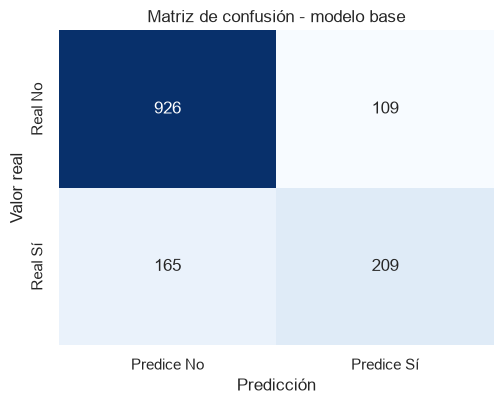

In [14]:
def classification_metrics(y_true, y_pred, y_probability=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_probability is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_probability)
    return pd.Series(metrics)


def plot_confusion(y_true, y_pred, title):
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5.2, 4.2))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predice No", "Predice Sí"],
        yticklabels=["Real No", "Real Sí"],
        ax=ax,
    )
    ax.set(title=title, xlabel="Predicción", ylabel="Valor real")
    plt.tight_layout()
    plt.show()
    return matrix


base_pipeline.fit(X_train, y_train)
y_pred_base = base_pipeline.predict(X_test)
y_prob_base = base_pipeline.predict_proba(X_test)[:, 1]

base_metrics = classification_metrics(y_test, y_pred_base, y_prob_base)
display(base_metrics.to_frame("Modelo base").T.round(3))
cm_base = plot_confusion(y_test, y_pred_base, "Matriz de confusión - modelo base")


La matriz se lee como `[[TN, FP], [FN, TP]]`. El modelo base consigue una *accuracy* cercana a 0,81, pero el baseline que siempre predice `No` ya obtiene aproximadamente 0,734. La mejora de accuracy es real pero insuficiente para describir el valor del modelo: debemos mirar cuántos abandonos detecta y cuántos descuentos innecesarios generaría.


In [15]:
majority_class = y_train.mode().iloc[0]
y_pred_naive = np.full(len(y_test), majority_class)
naive_metrics = classification_metrics(y_test, y_pred_naive)

baseline_comparison = pd.concat(
    [
        naive_metrics.rename("Naive: siempre clase mayoritaria"),
        base_metrics.drop("ROC-AUC").rename("Regresión logística base"),
    ],
    axis=1,
).T
display(baseline_comparison.round(3))

assert recall_score(y_test, y_pred_naive, zero_division=0) == 0


,Accuracy,Precision,Recall,F1
Naive: siempre clase mayoritaria,0.735,0.000,0.000,0.000
Regresión logística base,0.806,0.657,0.559,0.604


**¿Es accuracy una buena métrica?** No como única métrica. El modelo naive alcanza 73,46 % porque la clase `No` es mayoritaria, pero su recall para churn es 0: nunca identifica a un cliente que se fuga. En este problema, *precision* indica qué proporción de los descuentos enviados llega realmente a personas que se iban, *recall* indica qué proporción de las fugas logramos contactar y F1 resume el equilibrio entre ambas.


## 6. Segundo modelo: tratamiento del desbalance

Elegimos **ponderación de clases** (`class_weight="balanced"`). Es una técnica de costo sensible: durante el entrenamiento, los errores sobre la clase minoritaria reciben mayor peso, inversamente proporcional a su frecuencia. No inventa observaciones ni duplica clientes como el oversampling; busca mover la frontera para prestar más atención al churn.

La ponderación se configura dentro del estimador y se aprende solo con train. Conservamos exactamente las demás decisiones para que la comparación sea justa.


,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo base,0.806,0.657,0.559,0.604,0.842
Modelo con pesos balanceados,0.738,0.504,0.783,0.614,0.842


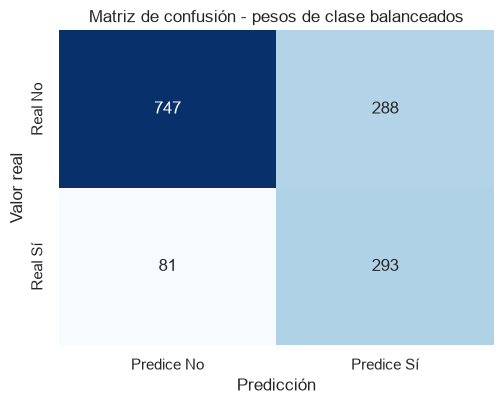

In [16]:
balanced_pipeline = build_logistic_pipeline(X_train, class_weight="balanced")
balanced_pipeline.fit(X_train, y_train)

y_pred_balanced = balanced_pipeline.predict(X_test)
y_prob_balanced = balanced_pipeline.predict_proba(X_test)[:, 1]

balanced_metrics = classification_metrics(
    y_test, y_pred_balanced, y_prob_balanced
)
model_comparison = pd.concat(
    [
        base_metrics.rename("Modelo base"),
        balanced_metrics.rename("Modelo con pesos balanceados"),
    ],
    axis=1,
).T
display(model_comparison.round(3))

cm_balanced = plot_confusion(
    y_test,
    y_pred_balanced,
    "Matriz de confusión - pesos de clase balanceados",
)


**Lectura comparativa:** el modelo balanceado sacrifica accuracy y precision, pero aumenta con fuerza el recall. Esto no significa que sea universalmente “mejor”: expresa una política de errores distinta. La decisión final depende del costo de enviar un descuento frente al valor de evitar una fuga.


## 7. Impacto económico de las métricas

La oferta es un descuento del 50 % durante 3 meses. Para un cliente con cargo mensual $M$, el desembolso nominal del descuento es:

$$0{,}50 \times 3 \times M = 1{,}5M$$

- **Falso positivo (FP):** se descuenta a alguien que no se iba. El costo es innecesario y, con los datos disponibles, puede aproximarse como `1.5 × MonthlyCharges`.
- **Falso negativo (FN):** no se contacta a alguien que sí se fuga. La pérdida relevante es el margen futuro del cliente, no solo tres meses de facturación; el dataset no informa margen, permanencia lograda por la campaña ni probabilidad de aceptar la oferta, por lo que no inventamos una cifra.
- **Verdadero positivo (TP):** también recibe un descuento, pero ese costo puede estar compensado por la retención. Sin una tasa causal de éxito de la campaña no podemos afirmar el beneficio neto.


In [17]:
def business_impact(model_name, y_true, y_pred, X_eval):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fp_mask = (y_pred == 1) & (y_true.to_numpy() == 0)
    contacted_mask = y_pred == 1

    return {
        "Modelo": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Costo desc. solo en FP (3 meses)": (
            1.5 * X_eval.loc[fp_mask, "MonthlyCharges"]
        ).sum(),
        "Desembolso total de descuentos (3 meses)": (
            1.5 * X_eval.loc[contacted_mask, "MonthlyCharges"]
        ).sum(),
    }


business_table = pd.DataFrame(
    [
        business_impact("Base", y_test, y_pred_base, X_test),
        business_impact(
            "Pesos balanceados", y_test, y_pred_balanced, X_test
        ),
    ]
).set_index("Modelo")

# Usamos redondeo estándar para no depender del paquete opcional jinja2.
display(business_table.round(2))

delta = business_table.loc["Pesos balanceados"] - business_table.loc["Base"]
print(
    f"El modelo balanceado detecta {int(delta['TP']):+d} fugas adicionales, "
    f"reduce los FN en {abs(int(delta['FN']))} y agrega {int(delta['FP']):+d} FP."
)
print(
    "Costo incremental de descuentos en falsos positivos: "
    f"{delta['Costo desc. solo en FP (3 meses)']:,.2f} unidades monetarias."
)


,TN,FP,FN,TP,Costo desc. solo en FP (3 meses),Desembolso total de descuentos (3 meses)
Modelo,,,,,,
Base,926,109,165,209,"13,163.020","37,817.480"
Pesos balanceados,747,288,81,293,"32,747.850","66,370.280"


El modelo balanceado detecta +84 fugas adicionales, reduce los FN en 84 y agrega +179 FP.
Costo incremental de descuentos en falsos positivos: 19,584.82 unidades monetarias.


### Decisión según el costo de la oferta

- **Si el descuento es muy costoso**, intentaríamos maximizar **precision**: cada contacto debe tener alta probabilidad de corresponder a una fuga real. Con el umbral actual, el modelo base es más prudente y genera muchos menos FP.
- **Si el descuento fuera casi gratuito**, priorizaríamos **recall**: conviene contactar a casi todos los clientes en riesgo aunque haya más FP. El modelo balanceado deja pasar muchos menos churners (menos FN).

La matriz confirma el intercambio, pero no basta para decidir rentabilidad. En producción elegiríamos el umbral que maximice valor esperado con margen por cliente, tasa de aceptación y efecto causal de la oferta. Aquí mantenemos el umbral 0,5 para comparar modelos sin ajustar sobre test.


# Parte II - Reformulación del problema

## 8. Nuevo target: contrato mensual

Reformulamos la tarea como: **predecir si un cliente pertenece a la modalidad `Month-to-month` (`1`) o a un contrato de uno/dos años (`0`)**. La pregunta puede orientar campañas de migración hacia contratos de mayor plazo.

Eliminamos:

- `Contract`, porque contiene directamente el target;
- `customerID`, porque es un identificador;
- `Churn`, porque puede ser un resultado posterior influido por el contrato. Usarlo daría una señal temporalmente cuestionable y confundiría predicción con consecuencia.

Esta parte mide asociación en un corte transversal. Para convertirla en un sistema de propensión realmente desplegable harían falta snapshots previos a la elección y una etiqueta futura (por ejemplo, aceptación de una oferta de migración).


In [18]:
y_contract = (df["Contract"] == "Month-to-month").astype(int)
X_contract = df.drop(columns=["customerID", "Churn", "Contract"])

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_contract,
    y_contract,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_contract,
)

contract_distribution = pd.DataFrame(
    {
        "cantidad": y_contract.value_counts().sort_index(),
        "porcentaje": 100 * y_contract.value_counts(normalize=True).sort_index(),
    },
    index=pd.Index([0, 1], name="contrato_mensual"),
)
display(contract_distribution.round(2))


,cantidad,porcentaje
contrato_mensual,,
0,3168,44.980
1,3875,55.020


Entrenamos una regresión logística simple, sin búsqueda de hiperparámetros. Reutilizamos el mismo diseño de pipeline y respetamos una nueva partición estratificada. `max_iter=2000` evita detener la optimización antes de converger; no es un ajuste para mejorar el score.


,Accuracy,Precision,Recall,F1,ROC-AUC
Naive: clase mayoritaria,0.550,0.550,1.000,0.710,0.500
Regresión logística,0.851,0.849,0.886,0.867,0.936


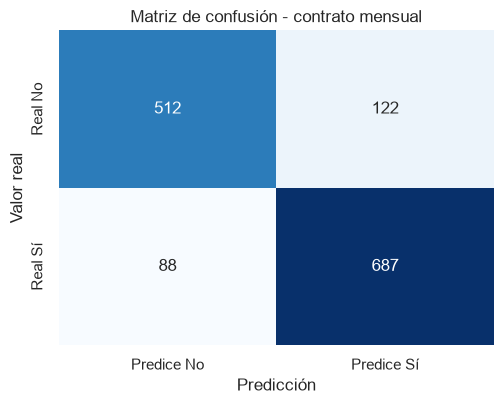

In [19]:
contract_pipeline = build_logistic_pipeline(Xc_train)
contract_pipeline.fit(Xc_train, yc_train)

yc_pred = contract_pipeline.predict(Xc_test)
yc_prob = contract_pipeline.predict_proba(Xc_test)[:, 1]
contract_metrics = classification_metrics(yc_test, yc_pred, yc_prob)

contract_majority = yc_train.mode().iloc[0]
yc_pred_naive = np.full(len(yc_test), contract_majority)
yc_prob_naive = np.full(len(yc_test), yc_train.mean())
contract_naive_metrics = classification_metrics(
    yc_test, yc_pred_naive, yc_prob_naive
)

contract_comparison = pd.concat(
    [
        contract_naive_metrics.rename("Naive: clase mayoritaria"),
        contract_metrics.rename("Regresión logística"),
    ],
    axis=1,
).T
display(contract_comparison.round(3))
cm_contract = plot_confusion(
    yc_test,
    yc_pred,
    "Matriz de confusión - contrato mensual",
)


**¿Es predecible el nuevo objetivo?** Sí, en sentido asociativo. El modelo supera ampliamente el baseline mayoritario tanto en accuracy como en F1 y logra buen desempeño en ambas clases. Es plausible porque antigüedad, forma de pago, cargos y servicios se relacionan con el tipo de contrato. Sin embargo, este resultado no demuestra que podamos anticipar una decisión futura: para eso necesitaríamos ordenar temporalmente las variables y validar sobre clientes de un período posterior.


# 9. Conclusiones

1. **Calidad de datos:** `TotalCharges` se cargaba como texto por 11 espacios en blanco. Todos correspondían a cuentas con antigüedad cero, por lo que se corrigieron a un acumulado de 0. No había filas ni identificadores duplicados.
2. **Prevención de leakage:** el split se realizó antes de cualquier transformación aprendida. Imputación defensiva, escalado y one-hot quedaron dentro del pipeline y, por lo tanto, también dentro de cada fold de validación.
3. **Validación:** Stratified 5-Fold produjo una estimación más estable que un único holdout y conservó la proporción de churn en todos los folds. Test se usó una sola vez al final.
4. **Modelo base:** mejora claramente al clasificador mayoritario, pero la accuracy por sí sola oculta que la clase positiva es minoritaria. Precision, recall, F1 y la matriz de confusión describen mejor la utilidad.
5. **Desbalance y negocio:** ponderar clases aumenta el recall y reduce falsos negativos, a costa de más falsos positivos, menor precision y mayor gasto en descuentos. El modelo preferible depende del costo de la oferta y del valor esperado de retener a un cliente.
6. **Nuevo problema:** el contrato mensual es predecible con las variables restantes y supera ampliamente su baseline. La interpretación es asociativa porque el dataset no aporta una dimensión temporal.

## Mejoras futuras

- estimar el efecto causal de la campaña mediante un experimento A/B; un buen clasificador de churn no garantiza que el descuento cambie la decisión;
- incorporar margen, costo de contacto, probabilidad de aceptación y valor de vida del cliente para optimizar un umbral económico;
- comparar modelos no lineales y calibrar probabilidades mediante validación cruzada, sin ajustar decisiones sobre test;
- validar en un período posterior para detectar deriva y medir generalización temporal;
- auditar desempeño por subgrupos y excluir atributos sensibles cuando no sean necesarios para la decisión.


---

## 10. Validaciones automáticas finales

Estas aserciones no reemplazan el análisis, pero hacen fallar el notebook si se rompe alguna condición central de reproducibilidad, separación de datos o consistencia de métricas.


In [20]:
assert df.shape == (7043, 21)
assert df["customerID"].is_unique
assert df.duplicated().sum() == 0
assert df.isna().sum().sum() == 0
assert X_train.index.intersection(X_test.index).empty
assert set(np.unique(y_pred_base)).issubset({0, 1})
assert set(np.unique(y_pred_balanced)).issubset({0, 1})
assert set(np.unique(yc_pred)).issubset({0, 1})
assert np.isclose(base_metrics["Accuracy"], (cm_base[0, 0] + cm_base[1, 1]) / cm_base.sum())
assert balanced_metrics["Recall"] > base_metrics["Recall"]
assert contract_metrics["Accuracy"] > contract_naive_metrics["Accuracy"]

print("✓ Todas las validaciones automáticas pasaron.")
print("✓ El notebook puede ejecutarse de principio a fin sin errores.")


✓ Todas las validaciones automáticas pasaron.
✓ El notebook puede ejecutarse de principio a fin sin errores.
